In [1]:
import pandas as pd

In [20]:
food = pd.read_csv(r"C:\Users\sophi\Documents\csv_folder\u_food_marketing.csv")

In [21]:
food.drop_duplicates(keep = False, inplace = True)

In [22]:
pd.set_option('display.max.columns', 50)

In [23]:
food.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Customer_Days,marital_Divorced,marital_Married,marital_Single,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
0,58138.0,0,0,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,63,2822,0,0,1,0,0,0,0,1,0,0,1529,1441,0
1,46344.0,1,1,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,66,2272,0,0,1,0,0,0,0,1,0,0,21,15,0
2,71613.0,0,0,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,55,2471,0,0,0,1,0,0,0,1,0,0,734,692,0
3,26646.0,1,0,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,36,2298,0,0,0,1,0,0,0,1,0,0,48,43,0
4,58293.0,1,0,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,39,2320,0,1,0,0,0,0,0,0,0,1,407,392,0


In [24]:
# our data has so many columns of a categoury that are spit up in further sub-catagories, 
# need to combine those columns as to use it efficiently


In [25]:
food['Total_Children'] = food[['Kidhome', 'Teenhome']].sum(axis = 1)

In [26]:
food.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1843 entries, 0 to 2204
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Income                1843 non-null   float64
 1   Kidhome               1843 non-null   int64  
 2   Teenhome              1843 non-null   int64  
 3   Recency               1843 non-null   int64  
 4   MntWines              1843 non-null   int64  
 5   MntFruits             1843 non-null   int64  
 6   MntMeatProducts       1843 non-null   int64  
 7   MntFishProducts       1843 non-null   int64  
 8   MntSweetProducts      1843 non-null   int64  
 9   MntGoldProds          1843 non-null   int64  
 10  NumDealsPurchases     1843 non-null   int64  
 11  NumWebPurchases       1843 non-null   int64  
 12  NumCatalogPurchases   1843 non-null   int64  
 13  NumStorePurchases     1843 non-null   int64  
 14  NumWebVisitsMonth     1843 non-null   int64  
 15  AcceptedCmp3          1843

In [27]:
# now to merge the marital status column into one, 

In [28]:
food['marital_Divorced'] = food['marital_Divorced'].replace({1:5,0:0})
food['marital_Married'] = food['marital_Married'].replace({1:4,0:0})
food['marital_Single'] = food['marital_Single'].replace({1:3,0:0})
food['marital_Together'] = food['marital_Together'].replace({1:2,0:0})

In [29]:
food['Marital_Status'] = food[['marital_Divorced', 'marital_Married', 'marital_Single', 'marital_Together', 'marital_Widow']].sum(axis = 1)

In [30]:
food['Marital_Status'].head()

0    3
1    3
2    2
3    2
4    4
Name: Marital_Status, dtype: int64

In [31]:
food['Marital_Status_Str'] = food['Marital_Status'].map({5:'Divorced', 4:'Married', 3:'Single', 2:'Together', 1:'Widow'})

In [32]:
food['Marital_Status_Str'].head()

0      Single
1      Single
2    Together
3    Together
4     Married
Name: Marital_Status_Str, dtype: object

In [33]:
# same thing will go with education

In [34]:
food['education_Basic']

0       0
1       0
2       0
3       0
4       0
       ..
2198    0
2200    0
2202    0
2203    0
2204    0
Name: education_Basic, Length: 1843, dtype: int64

In [35]:
food['education_Basic'] = food['education_Basic'].replace({1:2,0:0})
food['education_Graduation'] = food['education_Graduation'].replace({1:3,0:0})
food['education_Master'] = food['education_Master'].replace({1:4,0:0})
food['education_PhD'] = food['education_PhD'].replace({1:5,0:0})

In [36]:
food['Education_Status'] = food[['education_Basic', 'education_Graduation', 'education_Master', 'education_PhD', 'education_2n Cycle']].sum(axis = 1)

In [74]:
# now to sort out the accepted campaignes

In [19]:
food['Accepted_Campaigns'] = food[['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5']].sum(axis = 1)

In [29]:
food.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Customer_Days,marital_Divorced,marital_Married,marital_Single,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall,Total_Children,Marital_Status,Marital_Status_Str,Education_Status,Accepted_Campaigns
0,58138.0,0,0,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,63,2822,0,0,3,0,0,0,0,3,0,0,1529,1441,0,0,3,Single,3,0
1,46344.0,1,1,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,66,2272,0,0,3,0,0,0,0,3,0,0,21,15,0,2,3,Single,3,0
2,71613.0,0,0,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,55,2471,0,0,0,2,0,0,0,3,0,0,734,692,0,0,2,Together,3,0
3,26646.0,1,0,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,36,2298,0,0,0,2,0,0,0,3,0,0,48,43,0,1,2,Together,3,0
4,58293.0,1,0,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,39,2320,0,4,0,0,0,0,0,0,0,5,407,392,0,1,4,Married,5,0


In [22]:
## now lets start with our exploration

In [ ]:
### Perfromance of marketing activites, focusing the Compaigns

In [37]:
food.corr(method = 'pearson', numeric_only = True)['AcceptedCmpOverall'].sort_values(ascending = False)

AcceptedCmpOverall      1.000000
AcceptedCmp5            0.710378
AcceptedCmp1            0.688068
AcceptedCmp4            0.600645
MntWines                0.496881
MntTotal                0.452785
MntRegularProds         0.452599
AcceptedCmp2            0.442677
AcceptedCmp3            0.433521
Response                0.418309
Income                  0.384189
NumCatalogPurchases     0.361530
MntMeatProducts         0.314922
NumStorePurchases       0.217062
NumWebPurchases         0.204276
MntSweetProducts        0.196385
MntGoldProds            0.193886
MntFruits               0.169489
MntFishProducts         0.158858
Education_Status        0.035873
education_PhD           0.027418
marital_Widow           0.023738
education_Graduation    0.006934
marital_Married         0.006627
marital_Single          0.003951
education_Master       -0.003815
Marital_Status         -0.007273
marital_Divorced       -0.012311
marital_Together       -0.012562
Customer_Days          -0.013460
Recency   

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: >

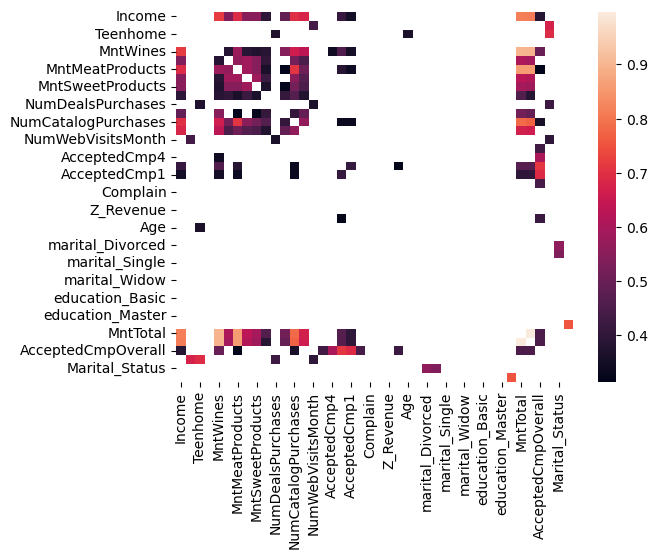

In [39]:
comp_corr = (food.corr(method = 'pearson', numeric_only = True))
comp_corr =comp_corr[(comp_corr >0.3) & (comp_corr <1)]
sns.heatmap(comp_corr)


In [40]:
## customer segmentation -- depending upon customer behaviour

In [41]:
age_groups = [(21,30), (31,40),(41,50),(51,60),(61,70),(71,85)]

def assign_age_group(Age):
    for age_range in age_groups:
        if age_range [0] <= Age <= age_range [1]:
            return f"{age_range[0]} - {age_range[1]}"
    return 'Unknown'

food['Age_group'] = food['Age'].apply(assign_age_group)

In [42]:
food[['Age', 'Age_group']].head()

,Age,Age_group
0,63,61 - 70
1,66,61 - 70
2,55,51 - 60
3,36,31 - 40
4,39,31 - 40


<Axes: xlabel='Age_group', ylabel='AcceptedCmpOverall'>

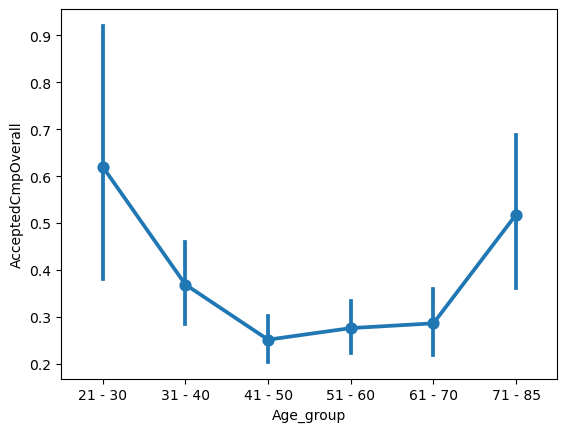

In [43]:
age_order =  ['21 - 30', '31 - 40','41 - 50','51 - 60','61 - 70','71 - 85']
sns.pointplot(data = food, x = 'Age_group', y = 'AcceptedCmpOverall', order = age_order)

In [44]:
food['Age_group'].value_counts()

Age_group
41 - 50    612
51 - 60    409
61 - 70    391
31 - 40    298
71 - 85     83
21 - 30     50
Name: count, dtype: int64

In [45]:
count = food['Age_group'].value_counts()
percentage = count/food.shape[0]
percent_food = percentage.reset_index()
percent_food.columns = ['age_group', 'percentage']
percent_food = percent_food.sort_values('age_group')
percent_food

,age_group,percentage
5,21 - 30,0.027130
3,31 - 40,0.161693
0,41 - 50,0.332067
1,51 - 60,0.221921
2,61 - 70,0.212154
4,71 - 85,0.045035


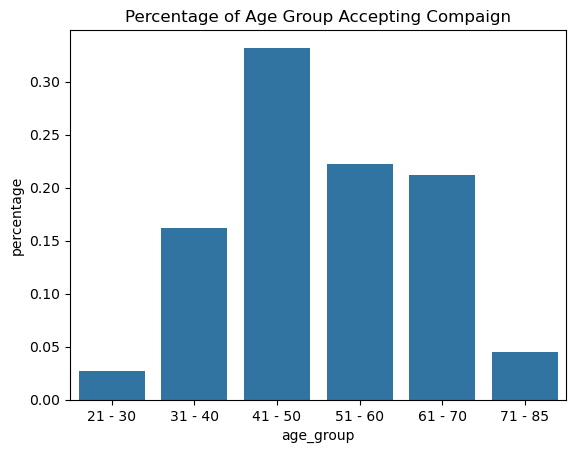

In [46]:
sns.barplot(x = 'age_group' , y = 'percentage', data = percent_food)
plt.title('Percentage of Age Group Accepting Compaign')
plt.show()

In [47]:
## Majority of audiance accepting the compaign lies between 31 and 70

In [48]:
# now lets dig on how much money they are spending


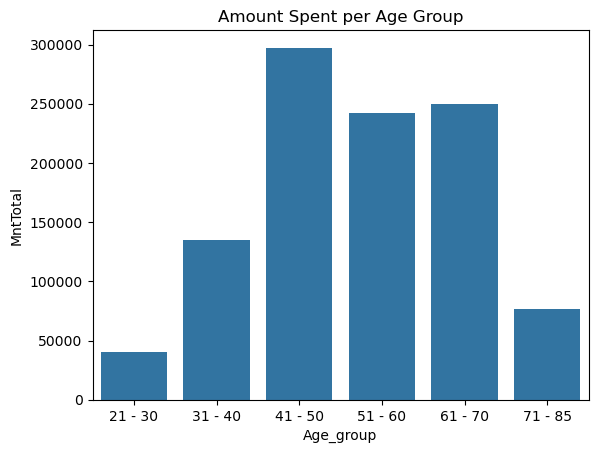

In [49]:
grouped_total_mnt = food.groupby('Age_group')['MntTotal'].sum().reset_index()

sns.barplot(x = 'Age_group', y = 'MntTotal', data = grouped_total_mnt)
plt.title('Amount Spent per Age Group')
plt.show()

In [50]:
## age group between 31 - 71 and up are accepting the compaign and spending high

In [51]:
food.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Customer_Days,marital_Divorced,marital_Married,marital_Single,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall,Total_Children,Marital_Status,Marital_Status_Str,Education_Status,Age_group
0,58138.0,0,0,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,63,2822,0,0,3,0,0,0,0,3,0,0,1529,1441,0,0,3,Single,3,61 - 70
1,46344.0,1,1,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,66,2272,0,0,3,0,0,0,0,3,0,0,21,15,0,2,3,Single,3,61 - 70
2,71613.0,0,0,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,55,2471,0,0,0,2,0,0,0,3,0,0,734,692,0,0,2,Together,3,51 - 60
3,26646.0,1,0,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,36,2298,0,0,0,2,0,0,0,3,0,0,48,43,0,1,2,Together,3,31 - 40
4,58293.0,1,0,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,39,2320,0,4,0,0,0,0,0,0,0,5,407,392,0,1,4,Married,5,31 - 40


In [52]:
## next the mode of purchase is also very important. lets have a view which mode is popular and which one needs attention

In [59]:
sum_mode_purchase = pd.DataFrame(food[['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']].sum(), columns = ['Sums'])

In [76]:
sum_mode_purchase = sum_mode_purchase.reset_index()

In [77]:
sum_mode_purchase.rename(columns = {'index':'Purchase_mode'}, inplace = True)

<Axes: xlabel='Purchase_mode', ylabel='Sums'>

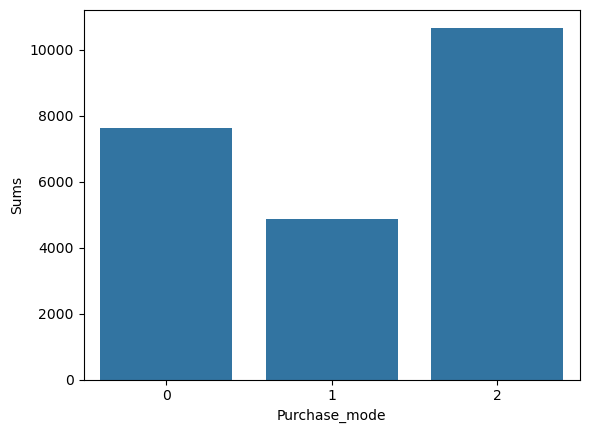

In [78]:
sns.barplot(x = 'Purchase_mode', y = 'Sums', data = sum_mode_purchase)

In [79]:
## now to see the effests on the purchase mode after filtering on the people who accepted the compaign

<Axes: xlabel='Purchase_mode', ylabel='Sums'>

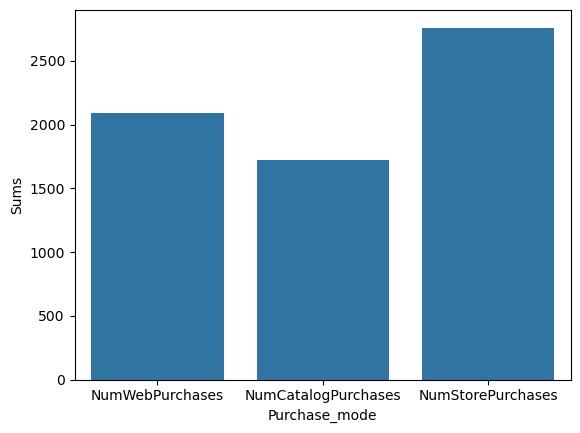

In [82]:
accpted_food = food[food['AcceptedCmpOverall']!=0]
sum_mode_purchase = pd.DataFrame(accpted_food[['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']].sum(), columns = ['Sums'])
sum_mode_purchase = sum_mode_purchase.reset_index()
sum_mode_purchase.rename(columns = {'index':'Purchase_mode'}, inplace = True)
sns.barplot(x = 'Purchase_mode', y = 'Sums', data = sum_mode_purchase)

In [83]:
## now to see the total amount purchsed on each purchase mode level

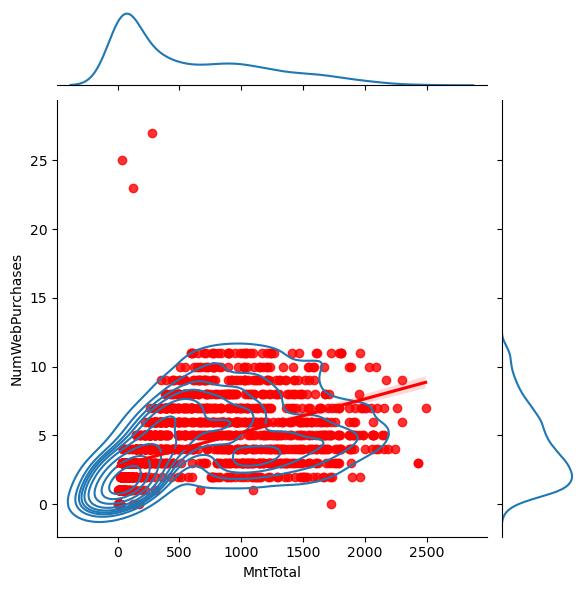

In [87]:
x = sns.jointplot(x = 'MntTotal', y = 'NumWebPurchases', data = food, kind = 'kde')
x.plot_joint(sns.regplot, color = 'r')

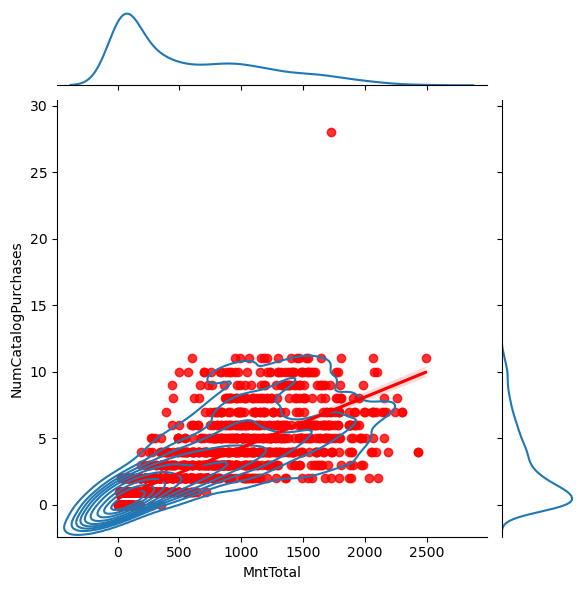

In [89]:
x = sns.jointplot(x = 'MntTotal', y = 'NumCatalogPurchases', data = food, kind = 'kde')
x.plot_joint(sns.regplot, color = 'r')

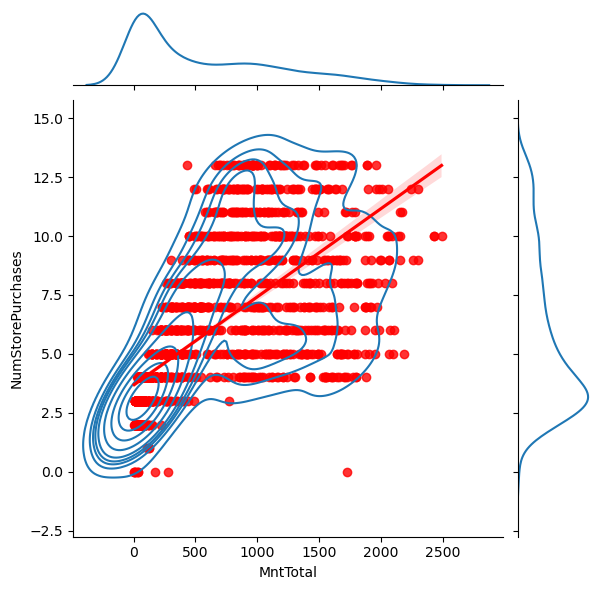

In [90]:
x = sns.jointplot(x = 'MntTotal', y = 'NumStorePurchases', data = food, kind = 'kde')
x.plot_joint(sns.regplot, color = 'r')

In [91]:
## the catalouge customers need boost, however, the web and in stroe purchases are already high can do beeter if more focused

<Axes: xlabel='Total_Children', ylabel='MntTotal'>

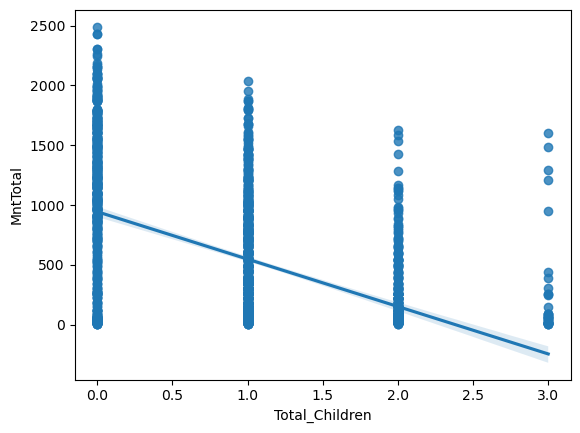

In [93]:
sns.regplot(x = 'Total_Children' ,y=  'MntTotal' , data = food)

In [94]:
## higher the number of children less amount spent 

<Axes: xlabel='Total_Children', ylabel='AcceptedCmpOverall'>

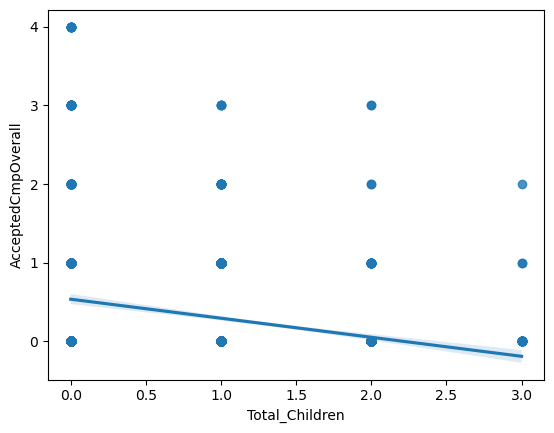

In [95]:
sns.regplot(x = 'Total_Children' ,y=  'AcceptedCmpOverall' , data = food)

In [96]:
## the rate of accepting compaign is also very low with more cildren

<Axes: xlabel='Education_Status', ylabel='AcceptedCmpOverall'>

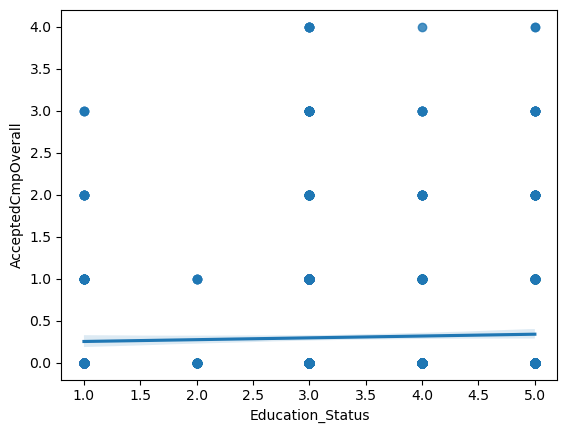

In [97]:
sns.regplot(x = 'Education_Status' ,y=  'AcceptedCmpOverall' , data = food)

In [98]:
## higher level of education tends to accept more compaigns

<Axes: xlabel='Education_Status', ylabel='MntTotal'>

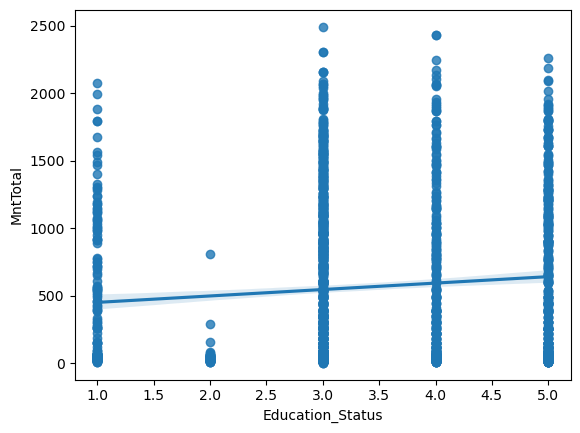

In [99]:
sns.regplot(x = 'Education_Status' ,y=  'MntTotal' , data = food)

In [100]:
## educatio dose not seem to be iportant segmentation 

<Axes: xlabel='Marital_Status_Str', ylabel='count'>

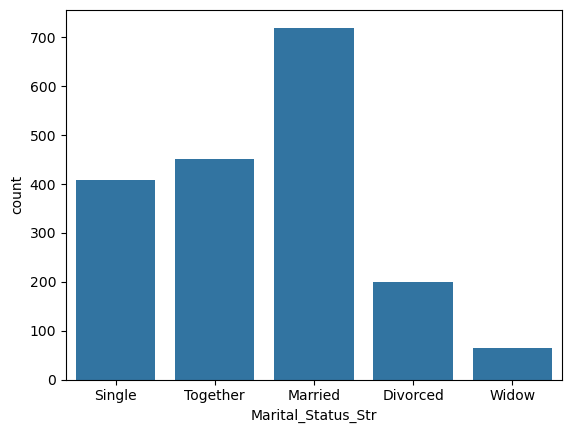

In [101]:
sns.countplot(x= 'Marital_Status_Str', data=food)

In [109]:
rel_food =food.groupby('Marital_Status_Str')['MntTotal'].sum().reset_index()

<Axes: xlabel='Marital_Status_Str', ylabel='MntTotal'>

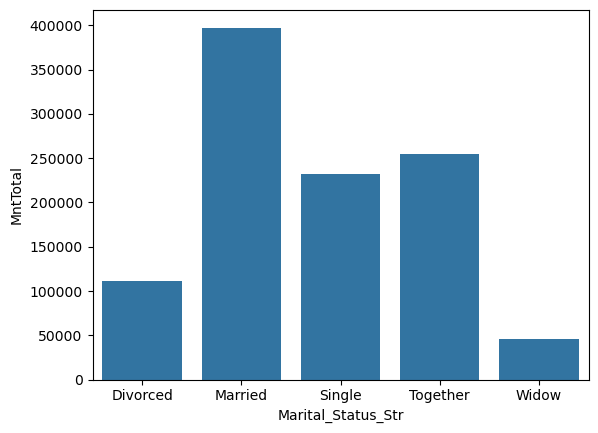

In [110]:
sns.barplot(data= rel_food, x= 'Marital_Status_Str', y= 'MntTotal')

In [111]:
## married people are spending more money

<Axes: xlabel='Marital_Status_Str', ylabel='MntTotal'>

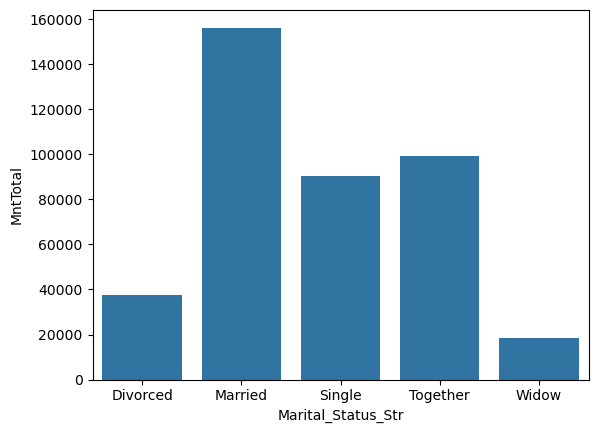

In [115]:
accpted_food = food[food['AcceptedCmpOverall']!=0]
rel_food =accpted_food.groupby('Marital_Status_Str')['MntTotal'].sum().reset_index()
sns.barplot(data= rel_food, x= 'Marital_Status_Str', y= 'MntTotal')

In [116]:
## married, single, and together people are spending more money and accepting more compaigns

Overall Findings

In [117]:
# Age: The age group between 30-70 are spending more money and acceptiond more compaigns.
#Purchase_Mode: The catalouge mode are accepting more compaigns, however in store purchase has the highest rate.
#People with kids: Focus on people with less kids is benifical
#Education: Education status has no signifucant affect on the purchase and compaigns accepting
#Marital_status: Marital status doesnt play any significant role, however, married, single and together people tend to sepnd more money

Money Making Suggestions

In [118]:
# Different segmentations of people mentioned above who are spending more should be prioratised to maintain our sale,
#however, in order to 